In [2]:
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.examples.tutorials.mnist import input_data
tf.logging.set_verbosity(tf.logging.ERROR)
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
mnist = input_data.read_data_sets("data/mnist", one_hot=True)

Successfully downloaded train-images-idx3-ubyte.gz 9912422 bytes.
Extracting data/mnist/train-images-idx3-ubyte.gz
Successfully downloaded train-labels-idx1-ubyte.gz 28881 bytes.
Extracting data/mnist/train-labels-idx1-ubyte.gz
Successfully downloaded t10k-images-idx3-ubyte.gz 1648877 bytes.
Extracting data/mnist/t10k-images-idx3-ubyte.gz
Successfully downloaded t10k-labels-idx1-ubyte.gz 4542 bytes.
Extracting data/mnist/t10k-labels-idx1-ubyte.gz


In the preceding code, data/mnist implies the location where we store the MNIST dataset, and one_hot=True implies that we are one-hot encoding the labels (0 to 9).

In [4]:
print("No of images in training set {}".format(mnist.train.images.shape))
print("No of labels in training set {}".format(mnist.train.labels.shape))
print("No of images in test set {}".format(mnist.test.images.shape))
print("No of labels in test set {}".format(mnist.test.labels.shape))



No of images in training set (55000, 784)
No of labels in training set (55000, 10)
No of images in test set (10000, 784)
No of labels in test set (10000, 10)


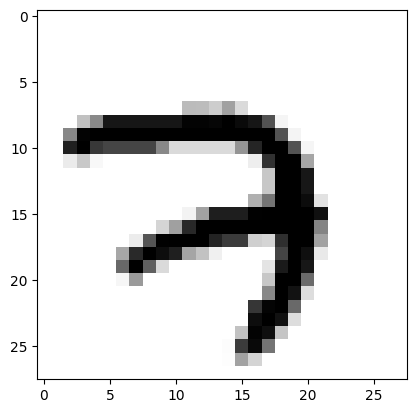

In [5]:
img1 = mnist.train.images[0].reshape(28,28)
plt.imshow(img1, cmap='Greys')

In [6]:
#number of neurons in input layer
num_input = 784
#num of neurons in hidden layer 1
num_hidden1 = 512
#num of neurons in hidden layer 2
num_hidden2 = 256
#num of neurons in hidden layer 3
num_hidden_3 = 128
#num of neurons in output layer
num_output = 10


In [7]:
with tf.name_scope('input'):
    X = tf.placeholder("float", [None, num_input])
with tf.name_scope('output'):
    Y = tf.placeholder("float", [None, num_output])

Since we have a four-layer network, we have four weights and four biases. We initialize our weights by drawing values from the truncated normal distribution with a standard deviation of 0.1. Remember, the dimensions of the weight matrix should be the number of neurons in the previous layer x the number of neurons in the current layer. For instance, the dimensions of weight matrix w3 should be the number of neurons in hidden layer 2 x the number of neurons in hidden layer 3.

In [8]:
with tf.name_scope('weights'):
    weights = {
                'w1': tf.Variable(tf.truncated_normal([num_input, num_hidden1], stddev=0.1),name='weight_1'),
                'w2': tf.Variable(tf.truncated_normal([num_hidden1, num_hidden2],stddev=0.1),name='weight_2'),
                'w3': tf.Variable(tf.truncated_normal([num_hidden2, num_hidden_3],stddev=0.1),name='weight_3'),
                'out': tf.Variable(tf.truncated_normal([num_hidden_3, num_output],stddev=0.1),name='weight_4'),
            }

In [9]:
with tf.name_scope('biases'):
    biases = {
                'b1': tf.Variable(tf.constant(0.1, shape=[num_hidden1]),name='bias_1'),
                'b2': tf.Variable(tf.constant(0.1, shape=[num_hidden2]),name='bias_2'),
                'b3': tf.Variable(tf.constant(0.1, shape=[num_hidden_3]),name='bias_3'),
                'out': tf.Variable(tf.constant(0.1, shape=[num_output]),name='bias_4')
            }

Forward propagation
Now we’ll define the forward propagation operation. We’ll use ReLU activations in all layers. In the last layers, we’ll apply sigmoid activation

In [10]:
with tf.name_scope('Model'):
    with tf.name_scope('layer1'):
        layer_1 = tf.nn.relu(tf.add(tf.matmul(X, weights['w1']),biases['b1']) )
    with tf.name_scope('layer2'):
        layer_2 = tf.nn.relu(tf.add(tf.matmul(layer_1, weights['w2']),biases['b2']))

    with tf.name_scope('layer3'):
        layer_3 = tf.nn.relu(tf.add(tf.matmul(layer_2, weights['w3']),biases['b3']))
    with tf.name_scope('output_layer'):
        y_hat = tf.nn.sigmoid(tf.matmul(layer_3, weights['out']) +biases['out'])


*** Computing loss and backpropagation ***
We’ll use softmax cross-entropy as our loss function. TensorFlow provides the tf.nn.softmax_cross_entropy_with_logits() function for computing softmax cross-entropy loss. It takes two parameters as inputs, logits and labels:
- The logits parameter specifies the logits predicted by our network; for example, y_hat
- The labels parameter specifies the actual labels; for example, true labels, Y

We take the mean of the loss function using tf.reduce_mean():

In [11]:
with tf.name_scope('Loss'):
    loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=y_hat,labels=Y))


Now, we need to minimize the loss using backpropagation.
we can use
TensorFlow’s optimizer:

In [12]:
learning_rate = 1e-4
optimizer = tf.train.AdamOptimizer(learning_rate).minimize(loss)

We calculate the accuracy of our model as follows:
• The y_hat parameter denotes the predicted probability for each class of our model. Since we have 10 classes, we will have 10 probabilities. If the probability is high at position 7, then it means that our network predicts the input image as digit 7 with high probability. The tf.argmax() function returns the index of the largest value. Thus, tf.argmax(y_hat,1) gives the index where the probability is high. Thus, if the probability is high at index 7, then it returns 7.
• The Y parameter denotes the actual labels, and they are the one-hot encoded values. That is, the Y parameter consists of zeros everywhere except at the position of the actual image, where it has a value of 1. For instance, if the input image is 7, then Y has a value of 0 at all indices except at index 7, where it has a value of 1. Thus, tf.argmax(Y,1) returns 7 because that is where we have a high value, 1.


Thus, tf.argmax(y_hat,1) gives the predicted digit, and tf.argmax(Y,1) gives us the actual digit.

The tf.equal(x, y) function takes x and y as inputs and returns the truth value of (x == y) element-wise. Thus, correct_pred = tf.equa (predicted_digit,actual_digit) consists of True where the actual and predicted digits are the same, and False where the actual and predicted digits are not the same. We convert the Boolean values in correct_pred into float values using TensorFlow’s cast operation, tf.cast(correct_ pred, tf.float32). After converting them into float values, we take the average using tf.reduce_mean().

Thus, tf.reduce_mean(tf.cast(correct_pred, tf.float32)) gives us the average correct predictions:

In [13]:
with tf.name_scope('Accuracy'):
    predicted_digit = tf.argmax(y_hat, 1)
    actual_digit = tf.argmax(Y, 1)
    correct_pred = tf.equal(predicted_digit,actual_digit)
    accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32))

Creating a summary

In [14]:
tf.summary.scalar("Accuracy", accuracy)
tf.summary.scalar("Loss", loss)

<tf.Tensor 'Loss_1:0' shape=() dtype=string>

In [15]:
merge_summary = tf.summary.merge_all()

In [16]:
init = tf.global_variables_initializer()

In [17]:
learning_rate = 1e-4
num_iterations = 1000
batch_size = 128

In [18]:
# Start the TensorFlow session:
with tf.Session() as sess:
    # Initialize all the variables:
    sess.run(init)
    # Save the event files:
    summary_writer = tf.summary.FileWriter('./graphs', graph=tf.get_default_graph())
    # Train the model for a number of iterations:
    for i in range(num_iterations):
        # Get a batch of data according to the batch size:
        batch_x, batch_y = mnist.train.next_batch(batch_size)
        # Train the network:
        sess.run(optimizer, feed_dict={ X: batch_x, Y: batch_y})
        # Print loss and accuracy for every 100th iteration:
        if i % 100 == 0:
            batch_loss, batch_accuracy,summary = sess.run([loss, accuracy, merge_summary],feed_dict={X: batch_x, Y: batch_y})
            #store all the summaries
            summary_writer.add_summary(summary, i)
            print('Iteration: {}, Loss: {}, Accuracy: {}'.format(i,batch_loss,batch_accuracy))


    
    

2024-09-26 08:32:46.570397: I tensorflow/core/platform/cpu_feature_guard.cc:141] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA
2024-09-26 08:32:46.693752: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2095995000 Hz
2024-09-26 08:32:46.708646: I tensorflow/compiler/xla/service/service.cc:150] XLA service 0x55f3fdb75fe0 executing computations on platform Host. Devices:
2024-09-26 08:32:46.708822: I tensorflow/compiler/xla/service/service.cc:158]   StreamExecutor device (0): <undefined>, <undefined>


Iteration: 0, Loss: 2.3245720863342285, Accuracy: 0.1015625
Iteration: 100, Loss: 1.7591042518615723, Accuracy: 0.8203125
Iteration: 200, Loss: 1.6535707712173462, Accuracy: 0.8671875
Iteration: 300, Loss: 1.6221568584442139, Accuracy: 0.859375
Iteration: 400, Loss: 1.575642704963684, Accuracy: 0.890625
Iteration: 500, Loss: 1.5514377355575562, Accuracy: 0.921875
Iteration: 600, Loss: 1.5661015510559082, Accuracy: 0.8984375
Iteration: 700, Loss: 1.5379297733306885, Accuracy: 0.90625
Iteration: 800, Loss: 1.5321035385131836, Accuracy: 0.9375
Iteration: 900, Loss: 1.5498732328414917, Accuracy: 0.8984375
